In [1]:
using NeuroDSL, CUDA, MLDatasets, Plots, Statistics, Random, LinearAlgebra

### ── Vérification CUDA ───

In [2]:
# ── Vérification CUDA ─────────────────────────────────────────────────────────
@assert CUDA.functional() "GPU CUDA n'est pas disponible"
CUDA.allowscalar(false)   # interdit les indexations scalaires

# ── Structures pour le pipeline double buffer ─────────────────────────────────
mutable struct MnistNodeV5
    symbol::Symbol
    value::Union{Nothing, CuArray{Float32}}
    gradient::Union{Nothing, CuArray{Float32}}
    stream::CUDA.CuStream
end

mutable struct MnistParallelGraph
    weights::Dict{Symbol, CuArray{Float32}}
    m1::Dict{Symbol, CuArray{Float32}}      # moment 1 pour AdamW
    m2::Dict{Symbol, CuArray{Float32}}      # moment 2 pour AdamW
    batch_A::Dict{Symbol, MnistNodeV5}
    batch_B::Dict{Symbol, MnistNodeV5}
end


### ── Initialisation du graphe avec deux jeux de buffers ──

In [3]:
# ── Initialisation du graphe avec deux jeux de buffers ────────────────────────
function initialiser_graphe_mnist(d_in::Int, d_hidden::Int, d_out::Int)
    weights = Dict(
        :W1 => CUDA.randn(Float32, d_hidden, d_in) .* 0.01f0,
        :W2 => CUDA.randn(Float32, d_out, d_hidden) .* 0.01f0,
    )
    m1 = Dict(:W1 => CUDA.zeros(Float32, size(weights[:W1])),
              :W2 => CUDA.zeros(Float32, size(weights[:W2])))
    m2 = Dict(:W1 => CUDA.zeros(Float32, size(weights[:W1])),
              :W2 => CUDA.zeros(Float32, size(weights[:W2])))

    stream_A = CUDA.CuStream()
    stream_B = CUDA.CuStream()
    symboles = [:x, :h, :pred, :y, :loss]

    function creer_node(s, stream)
        # Seuls :h, :pred, :loss ont une valeur allouée (les autres sont des vues sur les données)
        val = if s == :h
            CUDA.zeros(Float32, 1, d_hidden)   # taille sera réallouée dynamiquement
        elseif s == :pred
            CUDA.zeros(Float32, 1, d_out)
        elseif s == :loss
            CUDA.zeros(Float32, 1)
        else
            nothing
        end
        return MnistNodeV5(s, val, nothing, stream)
    end

    batch_A = Dict(s => creer_node(s, stream_A) for s in symboles)
    batch_B = Dict(s => creer_node(s, stream_B) for s in symboles)

    return MnistParallelGraph(weights, m1, m2, batch_A, batch_B)
end


initialiser_graphe_mnist (generic function with 1 method)

### ── Forward pass avec gestion dynamique des tailles ───

In [4]:
function execute_forward_graph_mnist!(slot::Dict{Symbol, MnistNodeV5},
                                       weights::Dict{Symbol, <:AbstractArray{Float32}},
                                       X_batch::CuArray{Float32},
                                       Y_batch::CuArray{Float32})
    st = slot[:x].stream
    slot[:x].value = X_batch
    slot[:y].value = Y_batch
    batch_size = size(X_batch, 1)

    if slot[:h].value === nothing || size(slot[:h].value, 1) != batch_size
        slot[:h].value = CUDA.zeros(Float32, batch_size, size(weights[:W1], 1))
    end

    CUDA.stream!(st) do
        CUDA.CUBLAS.gemm!('N', 'T', Float32(1), X_batch, weights[:W1], Float32(0), slot[:h].value)
        slot[:h].value .= max.(Float32(0), slot[:h].value)
    end

    if slot[:pred].value === nothing || size(slot[:pred].value, 1) != batch_size
        slot[:pred].value = CUDA.zeros(Float32, batch_size, size(weights[:W2], 1))
    end

    CUDA.stream!(st) do
        CUDA.CUBLAS.gemm!('N', 'T', Float32(1), slot[:h].value, weights[:W2], Float32(0), slot[:pred].value)
    end

    if slot[:loss].value === nothing
        slot[:loss].value = CUDA.zeros(Float32, 1)
    end

    CUDA.stream!(st) do
        max_vals = maximum(slot[:pred].value, dims=2)
        exps = exp.(slot[:pred].value .- max_vals)
        probs = exps ./ sum(exps, dims=2)
        loss_val = -sum(Y_batch .* log.(probs .+ Float32(1e-8))) / batch_size
        slot[:loss].value .= loss_val
    end
end

execute_forward_graph_mnist! (generic function with 1 method)

### ── Backward pass (gradients accumulés dans un dictionnaire externe) ──

In [5]:
function execute_backward_graph_mnist!(slot::Dict{Symbol, MnistNodeV5},
                                        weights::Dict{Symbol, <:AbstractArray{Float32}},
                                        grads_accumulated::Dict{Symbol, <:AbstractArray{Float32}})
    st = slot[:x].stream
    N = size(slot[:x].value, 1)

    if slot[:pred].gradient === nothing || size(slot[:pred].gradient) != size(slot[:pred].value)
        slot[:pred].gradient = CUDA.zeros(Float32, size(slot[:pred].value))
    end

    CUDA.stream!(st) do
        max_vals = maximum(slot[:pred].value, dims=2)
        exps = exp.(slot[:pred].value .- max_vals)
        probs = exps ./ sum(exps, dims=2)
        slot[:pred].gradient .= (probs .- slot[:y].value) ./ Float32(N)
    end

    CUDA.stream!(st) do
        CUDA.CUBLAS.gemm!('T', 'N', Float32(1), slot[:pred].gradient, slot[:h].value, Float32(1), grads_accumulated[:W2])
    end

    if slot[:h].gradient === nothing || size(slot[:h].gradient) != size(slot[:h].value)
        slot[:h].gradient = CUDA.zeros(Float32, size(slot[:h].value))
    end

    CUDA.stream!(st) do
        CUDA.CUBLAS.gemm!('N', 'N', Float32(1), slot[:pred].gradient, weights[:W2], Float32(0), slot[:h].gradient)
        slot[:h].gradient .= slot[:h].gradient .* (slot[:h].value .> Float32(0))
    end

    CUDA.stream!(st) do
        CUDA.CUBLAS.gemm!('T', 'N', Float32(1), slot[:h].gradient, slot[:x].value, Float32(1), grads_accumulated[:W1])
    end
end

execute_backward_graph_mnist! (generic function with 1 method)

### ── Mise à jour des poids avec AdamW (sur GPU via le kernel de NeuroDSL)

In [6]:
function update_weights!(graph::MnistParallelGraph,
                         grads::Dict{Symbol, <:AbstractArray{Float32}},
                         lr::Float32,
                         epoch::Int)
    for w in [:W1, :W2]
        adamw_step!(Backend.CUDADevice(),
                    graph.weights[w], grads[w],
                    graph.m1[w], graph.m2[w],
                    lr, Float32(0.9), Float32(0.999), Float32(1e-8), Int32(epoch), Float32(1.0), Float32(0.01))
    end
end

update_weights! (generic function with 1 method)

### ── Pipeline d'entraînement avec double buffering ───

In [7]:
function train_mnist_pipeline!(graph::MnistParallelGraph,
                               x_batches::Vector{<:CuArray{Float32}},
                               y_batches::Vector{<:CuArray{Float32}},
                               lr::Float32,
                               epoch::Int)
    grads = Dict(
        :W1 => CUDA.zeros(Float32, size(graph.weights[:W1])),
        :W2 => CUDA.zeros(Float32, size(graph.weights[:W2]))
    )
    for i in eachindex(x_batches)
        slot = (i % 2 == 0) ? graph.batch_A : graph.batch_B
        execute_forward_graph_mnist!(slot, graph.weights, x_batches[i], y_batches[i])
        execute_backward_graph_mnist!(slot, graph.weights, grads)
        CUDA.synchronize(slot[:x].stream)
        update_weights!(graph, grads, lr, epoch)
    end
end

train_mnist_pipeline! (generic function with 1 method)

### ── Calcul de précision (sur GPU, sans copie inutile) ────

In [8]:
function calculer_accuracy(slot::Dict{Symbol, MnistNodeV5})
    pred = slot[:pred].value
    y    = slot[:y].value
    batch_size = size(pred, 1)
    correct = sum(argmax(pred, dims=2) .== argmax(y, dims=2))
    return Float32(correct) / batch_size * 100
end

calculer_accuracy (generic function with 1 method)

### ── Préparation des données MNIST (avec MLDatasets) ──

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6. Préparation des données MNIST (corrigée, avec MLDatasets)
# ═══════════════════════════════════════════════════════════════════════════════
using MLDatasets

function preparer_mnist(split::Symbol, batch_size::Int)
    dataset = MLDatasets.MNIST(split=split)
    imgs = Float32.(dataset.features) / 255.0f0   # normalisation (le f0 ici est correct car attaché à 255)
    labels = dataset.targets
    N = size(imgs, 3)
    X = reshape(permutedims(imgs, (3,2,1)), N, 784)
    Y = zeros(Float32, N, 10)
    for i in 1:N
        Y[i, labels[i] + 1] = 1.0f0   # ici 1.0f0 est correct
    end
    x_batches = [CuArray(X[i:min(i+batch_size-1, N), :]) for i in 1:batch_size:N]
    y_batches = [CuArray(Y[i:min(i+batch_size-1, N), :]) for i in 1:batch_size:N]
    return x_batches, y_batches
end

preparer_mnist (generic function with 1 method)

###  Exécution principale

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Exécution principale
# ═══════════════════════════════════════════════════════════════════════════════
using Printf
println("🚀 Chargement des données MNIST...")
batch_size = 128
x_train, y_train = preparer_mnist(:train, batch_size)
x_test,  y_test  = preparer_mnist(:test,  batch_size)

println("📐 Création du graphe (784 → 128 → 10)...")
graphe = initialiser_graphe_mnist(784, 128, 10)

println("🏋️ Début de l'entraînement (3 époques)...")
epochs = 20
lr = 0.001f0
train_losses = Float32[]
test_accuracies = Float32[]

for epoch in 1:epochs
    # Entraînement
    train_mnist_pipeline!(graphe, x_train, y_train, lr, epoch)
    # Calcul de la loss moyenne (exemple sur un batch, pour suivi)
    slot = graphe.batch_A
    loss_val = slot[:loss].value === nothing ? NaN : Array(slot[:loss].value)[1]
    push!(train_losses, loss_val)
    # Évaluation sur le jeu de test (en utilisant un batch unique, simplifié)
    # Pour une évaluation complète, il faudrait parcourir tous les batches de test.
    # Ici on prend le premier batch comme indicateur.
    execute_forward_graph_mnist!(graphe.batch_A, graphe.weights, x_test[1], y_test[1])
    acc = calculer_accuracy(graphe.batch_A)
    push!(test_accuracies, acc)
    @printf("Époque %d | Loss moyenne (approx) = %.4f | Précision test (1er batch) = %.2f%%\n",
            epoch, loss_val, acc)
end

println("✅ Entraînement terminé.")

🚀 Chargement des données MNIST...
📐 Création du graphe (784 → 128 → 10)...
🏋️ Début de l'entraînement (3 époques)...
Époque 1 | Loss moyenne (approx) = 1.1901 | Précision test (1er batch) = 70.31%
Époque 2 | Loss moyenne (approx) = 0.8464 | Précision test (1er batch) = 75.00%
Époque 3 | Loss moyenne (approx) = 0.6826 | Précision test (1er batch) = 76.56%
Époque 4 | Loss moyenne (approx) = 0.5813 | Précision test (1er batch) = 79.69%
Époque 5 | Loss moyenne (approx) = 0.5100 | Précision test (1er batch) = 81.25%
Époque 6 | Loss moyenne (approx) = 0.4559 | Précision test (1er batch) = 80.47%
Époque 7 | Loss moyenne (approx) = 0.4128 | Précision test (1er batch) = 79.69%
Époque 8 | Loss moyenne (approx) = 0.3773 | Précision test (1er batch) = 81.25%
Époque 9 | Loss moyenne (approx) = 0.3475 | Précision test (1er batch) = 81.25%
Époque 10 | Loss moyenne (approx) = 0.3219 | Précision test (1er batch) = 81.25%
Époque 11 | Loss moyenne (approx) = 0.2998 | Précision test (1er batch) = 80.47%
É

###  Visualisation rapide

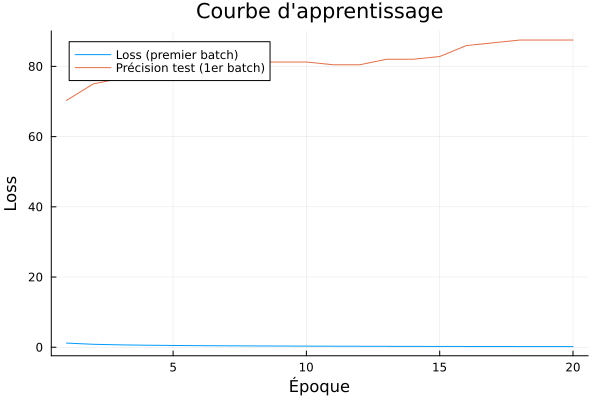

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Visualisation rapide
# ═══════════════════════════════════════════════════════════════════════════════
plot(1:epochs, train_losses, label="Loss (premier batch)", xlabel="Époque", ylabel="Loss", title="Courbe d'apprentissage")
plot!(1:epochs, test_accuracies, label="Précision test (1er batch)")

In [20]:

function roc_curve(y_true::Vector{Int}, y_score::Vector{Float32})
    # y_true : 0 ou 1 (vrai label binaire)
    # y_score : probabilité prédite (entre 0 et 1)
    pairs = [(score, label) for (score, label) in zip(y_score, y_true)]
    sort!(pairs, by=x->x[1], rev=true)
    tpr = Float64[]
    fpr = Float64[]
    n_pos = count(==(1), y_true)
    n_neg = count(==(0), y_true)
    tp = 0
    fp = 0
    for (_, label) in pairs
        if label == 1
            tp += 1
        else
            fp += 1
        end
        push!(tpr, tp / n_pos)
        push!(fpr, fp / n_neg)
    end
    # Ajout du point (0,0) pour une courbe complète
    return [0.0; fpr], [0.0; tpr]
end

function auc(fpr::Vector{Float64}, tpr::Vector{Float64})
    # Intégration trapézoïdale
    sum_auc = 0.0
    for i in 2:length(fpr)
        sum_auc += (fpr[i] - fpr[i-1]) * (tpr[i] + tpr[i-1]) / 2
    end
    return sum_auc
end

auc (generic function with 1 method)

In [28]:
function evaluer_modele_complet(graphe, x_test, y_test)
    total_correct = 0
    total_samples = 0
    all_probs = Float32[]
    all_labels = Int[]
    
    for i in eachindex(x_test)
        execute_forward_graph_mnist!(graphe.batch_A, graphe.weights, x_test[i], y_test[i])
        logits = graphe.batch_A[:pred].value
        max_vals = maximum(logits, dims=2)
        exps = exp.(logits .- max_vals)
        probs = exps ./ sum(exps, dims=2)
        probs_cpu = Array(probs)
        
        # Récupération des labels vrais (0-9) en passant par CPU
        y_true_gpu = argmax(y_test[i], dims=2)  # CuArray{CartesianIndex{2}}
        y_true_cpu = Array(y_true_gpu)          # conversion en Array sur CPU
        labels_cpu = [idx[2] - 1 for idx in y_true_cpu]  # maintenant sûr
        
        # Prédictions (comparaison sur GPU pour le comptage)
        preds = argmax(probs, dims=2)
        targets = argmax(y_test[i], dims=2)
        correct = sum(preds .== targets)
        total_correct += correct
        total_samples += size(x_test[i], 1)
        
        if i == 1
            all_probs = probs_cpu
        else
            all_probs = vcat(all_probs, probs_cpu)
        end
        append!(all_labels, labels_cpu)
    end
    
    accuracy = 100 * total_correct / total_samples
    return accuracy, all_probs, all_labels
end

evaluer_modele_complet (generic function with 1 method)

In [29]:
using Plots

function plot_roc_curves(probas::Matrix{Float32}, labels::Vector{Int})
    num_classes = size(probas, 2)
    plt = plot(title="Courbes ROC - MNIST (one-vs-rest)",
               xlabel="Taux de faux positifs (FPR)",
               ylabel="Taux de vrais positifs (TPR)",
               legend=:bottomright,
               size=(800, 600))
    
    for c in 0:num_classes-1
        y_true = [label == c ? 1 : 0 for label in labels]
        y_score = probas[:, c+1]
        fpr, tpr = roc_curve(y_true, y_score)
        auc_val = auc(fpr, tpr)
        plot!(fpr, tpr, label="Classe $c (AUC = $(round(auc_val, digits=3)))", linewidth=2)
    end
    plot!(plt)
end

plot_roc_curves (generic function with 1 method)

🔍 Évaluation complète sur l'ensemble de test...
Précision totale sur 10000 images : 88.43%


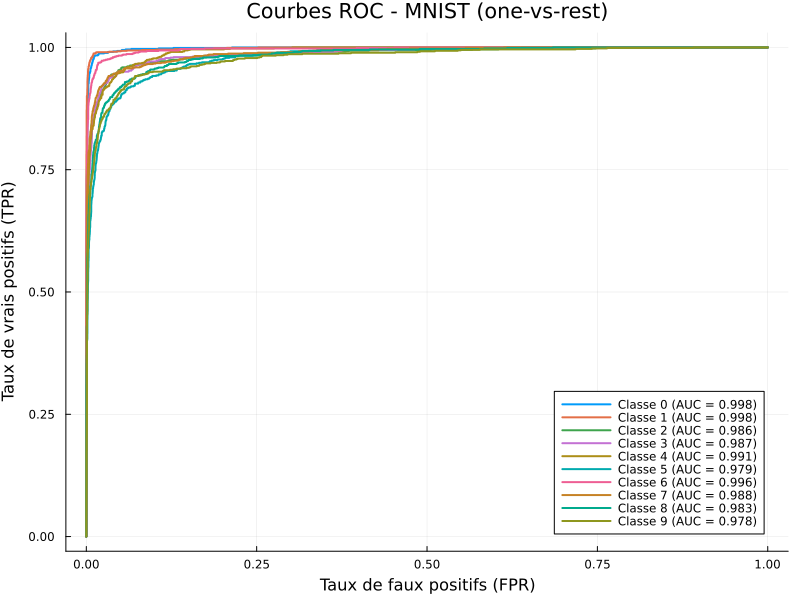

In [30]:
println("🔍 Évaluation complète sur l'ensemble de test...")
acc, probas, labels = evaluer_modele_complet(graphe, x_test, y_test)
println("Précision totale sur ", length(labels), " images : $(round(acc, digits=2))%")

# Tracé des courbes ROC
plot_roc_curves(probas, labels)

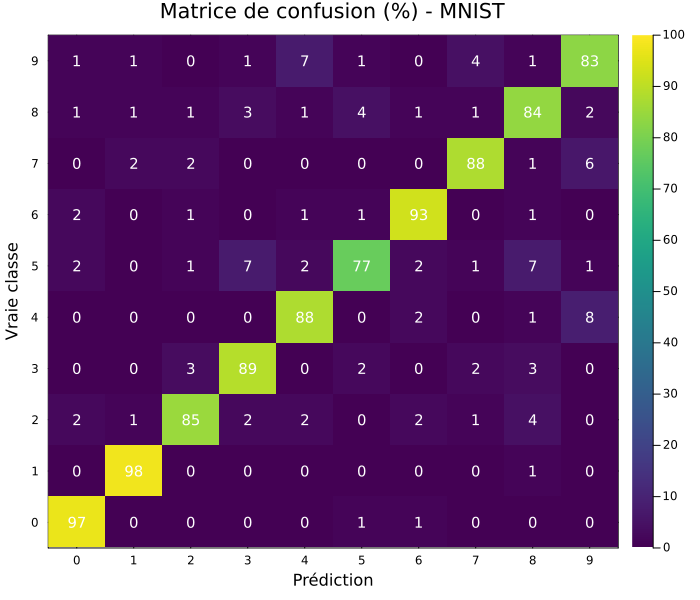

In [ ]:
using Plots, StatsBase

conf_mat = matrice_confusion(probas, labels)   # votre matrice
conf_mat_pct = round.(Int, 100 * conf_mat ./ sum(conf_mat, dims=2))

# Heatmap avec axes 0..9, mais les cellules sont centrées sur les demis
heatmap(0.5:1:9.5, 0.5:1:9.5, conf_mat_pct,
        xlabel="Prédiction", ylabel="Vraie classe",
        title="Matrice de confusion (%) - MNIST",
        color=:viridis, clims=(0,100),
        size=(700,600),
        xticks=(0.5:1:9.5, string.(0:9)),
        yticks=(0.5:1:9.5, string.(0:9)),
        framestyle=:box)

# Annotations aux mêmes coordonnées (centres des cellules)
for i in 1:10
    for j in 1:10
        annotate!(j-0.5, i-0.5, text(string(conf_mat_pct[i,j]), :white, :center, 10))
    end
end

current()